In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [ ]:

# Raw data string for the second dataset
data2 = """
EA - 4 class

None
Subject 1 Test Accuracy: 0.61
Subject 2 Test Accuracy: 0.45
Subject 3 Test Accuracy: 0.73
Subject 4 Test Accuracy: 0.39
Subject 5 Test Accuracy: 0.36
Subject 6 Test Accuracy: 0.33
Subject 7 Test Accuracy: 0.58
Subject 8 Test Accuracy: 0.59
Subject 9 Test Accuracy: 0.68
Mean Cross-Validation Accuracy: 0.53 ± 0.14

Standard
Subject 1 Test Accuracy: 0.76
Subject 2 Test Accuracy: 0.52
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.66
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.80
Subject 8 Test Accuracy: 0.81
Subject 9 Test Accuracy: 0.67
Mean Cross-Validation Accuracy: 0.65 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.69
Subject 2 Test Accuracy: 0.34
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.52
Subject 5 Test Accuracy: 0.35
Subject 6 Test Accuracy: 0.46
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.67
Subject 9 Test Accuracy: 0.68
Mean Cross-Validation Accuracy: 0.56 ± 0.15

Beta
Subject 1 Test Accuracy: 0.82
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.82
Subject 4 Test Accuracy: 0.63
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.55
Subject 7 Test Accuracy: 0.88
Subject 8 Test Accuracy: 0.60
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.65 ± 0.16

CSP+LDA: 4 class

None
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.43
Subject 3 Test Accuracy: 0.73
Subject 4 Test Accuracy: 0.41
Subject 5 Test Accuracy: 0.25
Subject 6 Test Accuracy: 0.31
Subject 7 Test Accuracy: 0.49
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.50 ± 0.15

Standard
Subject 1 Test Accuracy: 0.78
Subject 2 Test Accuracy: 0.48
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.62
Subject 5 Test Accuracy: 0.33
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.62
Subject 8 Test Accuracy: 0.82
Subject 9 Test Accuracy: 0.64
Mean Cross-Validation Accuracy: 0.61 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.67
Subject 2 Test Accuracy: 0.28
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.47
Subject 5 Test Accuracy: 0.36
Subject 6 Test Accuracy: 0.47
Subject 7 Test Accuracy: 0.50
Subject 8 Test Accuracy: 0.67
Subject 9 Test Accuracy: 0.63
Mean Cross-Validation Accuracy: 0.52 ± 0.14

Beta
Subject 1 Test Accuracy: 0.79
Subject 2 Test Accuracy: 0.50
Subject 3 Test Accuracy: 0.80
Subject 4 Test Accuracy: 0.61
Subject 5 Test Accuracy: 0.34
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.75
Subject 8 Test Accuracy: 0.52
Subject 9 Test Accuracy: 0.60
Mean Cross-Validation Accuracy: 0.60 ± 0.14

MDRM: 4 Class:

None
Subject 1 Test Accuracy: 0.65
Subject 2 Test Accuracy: 0.42
Subject 3 Test Accuracy: 0.67
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.26
Subject 6 Test Accuracy: 0.40
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.75
Subject 9 Test Accuracy: 0.70
Mean Cross-Validation Accuracy: 0.55 ± 0.15

Standard
Subject 1 Test Accuracy: 0.81
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.70
Subject 4 Test Accuracy: 0.67
Subject 5 Test Accuracy: 0.44
Subject 6 Test Accuracy: 0.49
Subject 7 Test Accuracy: 0.60
Subject 8 Test Accuracy: 0.74
Subject 9 Test Accuracy: 0.76
Mean Cross-Validation Accuracy: 0.64 ± 0.12
Alpha
Subject 1 Test Accuracy: 0.76
Subject 2 Test Accuracy: 0.35
Subject 3 Test Accuracy: 0.70
Subject 4 Test Accuracy: 0.49
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.44
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.77
Subject 9 Test Accuracy: 0.76
Mean Cross-Validation Accuracy: 0.58 ± 0.16

Beta
Subject 1 Test Accuracy: 0.81
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.67
Subject 4 Test Accuracy: 0.68
Subject 5 Test Accuracy: 0.47
Subject 6 Test Accuracy: 0.47
Subject 7 Test Accuracy: 0.71
Subject 8 Test Accuracy: 0.62
Subject 9 Test Accuracy: 0.70
Mean Cross-Validation Accuracy: 0.63 ± 0.11

RA-MDRM: 4 class

None
Subject 1 Test Accuracy: 0.66
Subject 2 Test Accuracy: 0.46
Subject 3 Test Accuracy: 0.67
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.44
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.76
Subject 9 Test Accuracy: 0.75
Mean Cross-Validation Accuracy: 0.59 ± 0.12

Standard
Subject 1 Test Accuracy: 0.77
Subject 2 Test Accuracy: 0.55
Subject 3 Test Accuracy: 0.79
Subject 4 Test Accuracy: 0.66
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.48
Subject 7 Test Accuracy: 0.76
Subject 8 Test Accuracy: 0.77
Subject 9 Test Accuracy: 0.76
Mean Cross-Validation Accuracy: 0.66 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.71
Subject 2 Test Accuracy: 0.40
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.44
Subject 6 Test Accuracy: 0.42
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.81
Subject 9 Test Accuracy: 0.80
Mean Cross-Validation Accuracy: 0.61 ± 0.16

Beta
Subject 1 Test Accuracy: 0.83
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.76
Subject 4 Test Accuracy: 0.67
Subject 5 Test Accuracy: 0.46
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.84
Subject 8 Test Accuracy: 0.69
Subject 9 Test Accuracy: 0.72
Mean Cross-Validation Accuracy: 0.67 ± 0.13


LEA: 4 class

None
Subject 1 Test Accuracy: 0.65
Subject 2 Test Accuracy: 0.47
Subject 3 Test Accuracy: 0.71
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.45
Subject 7 Test Accuracy: 0.65
Subject 8 Test Accuracy: 0.78
Subject 9 Test Accuracy: 0.71

Mean Cross-Validation Accuracy: 0.60 ± 0.12

Standard
Subject 1 Test Accuracy: 0.80
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.81
Subject 4 Test Accuracy: 0.64
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.48
Subject 7 Test Accuracy: 0.77
Subject 8 Test Accuracy: 0.80
Subject 9 Test Accuracy: 0.73

Mean Cross-Validation Accuracy: 0.67 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.77
Subject 2 Test Accuracy: 0.39
Subject 3 Test Accuracy: 0.80
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.43
Subject 7 Test Accuracy: 0.61
Subject 8 Test Accuracy: 0.81
Subject 9 Test Accuracy: 0.76

Mean Cross-Validation Accuracy: 0.61 ± 0.16

Beta
Subject 1 Test Accuracy: 0.83
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.76
Subject 4 Test Accuracy: 0.65
Subject 5 Test Accuracy: 0.44
Subject 6 Test Accuracy: 0.52
Subject 7 Test Accuracy: 0.85
Subject 8 Test Accuracy: 0.76
Subject 9 Test Accuracy: 0.68

Mean Cross-Validation Accuracy: 0.67 ± 0.13


TSA: 4 class
None
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.38
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.48
Subject 5 Test Accuracy: 0.32
Subject 6 Test Accuracy: 0.35
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.75
Subject 9 Test Accuracy: 0.67

Mean Cross-Validation Accuracy: 0.53 ± 0.15

Standard
Subject 1 Test Accuracy: 0.80
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.78
Subject 4 Test Accuracy: 0.56
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.47
Subject 7 Test Accuracy: 0.68
Subject 8 Test Accuracy: 0.75
Subject 9 Test Accuracy: 0.70

Mean Cross-Validation Accuracy: 0.63 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.73
Subject 2 Test Accuracy: 0.37
Subject 3 Test Accuracy: 0.75
Subject 4 Test Accuracy: 0.47
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.35
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.78
Subject 9 Test Accuracy: 0.73

Mean Cross-Validation Accuracy: 0.57 ± 0.17

Beta
Subject 1 Test Accuracy: 0.74
Subject 2 Test Accuracy: 0.53
Subject 3 Test Accuracy: 0.73
Subject 4 Test Accuracy: 0.66
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.45
Subject 7 Test Accuracy: 0.79
Subject 8 Test Accuracy: 0.65
Subject 9 Test Accuracy: 0.71

Mean Cross-Validation Accuracy: 0.63 ± 0.13


RPA: 4 class

None
Subject 1 Test Accuracy: 0.55
Subject 2 Test Accuracy: 0.35
Subject 3 Test Accuracy: 0.46
Subject 4 Test Accuracy: 0.44
Subject 5 Test Accuracy: 0.44
Subject 6 Test Accuracy: 0.37
Subject 7 Test Accuracy: 0.46
Subject 8 Test Accuracy: 0.65
Subject 9 Test Accuracy: 0.65

Mean Cross-Validation Accuracy: 0.49 ± 0.10
Standard
Subject 1 Test Accuracy: 0.65
Subject 2 Test Accuracy: 0.37
Subject 3 Test Accuracy: 0.66
Subject 4 Test Accuracy: 0.59
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.38
Subject 7 Test Accuracy: 0.62
Subject 8 Test Accuracy: 0.63
Subject 9 Test Accuracy: 0.67

Mean Cross-Validation Accuracy: 0.55 ± 0.13

Alpha
Subject 1 Test Accuracy: 0.66
Subject 2 Test Accuracy: 0.33
Subject 3 Test Accuracy: 0.63
Subject 4 Test Accuracy: 0.48
Subject 5 Test Accuracy: 0.37
Subject 6 Test Accuracy: 0.36
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.69

Mean Cross-Validation Accuracy: 0.52 ± 0.13

Beta
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.39
Subject 3 Test Accuracy: 0.57
Subject 4 Test Accuracy: 0.52
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.36
Subject 7 Test Accuracy: 0.66
Subject 8 Test Accuracy: 0.60
Subject 9 Test Accuracy: 0.62

Mean Cross-Validation Accuracy: 0.52 ± 0.11

MEKT: 4 class

None
Subject 1 Test Accuracy: 0.21
Subject 2 Test Accuracy: 0.55
Subject 3 Test Accuracy: 0.72
Subject 4 Test Accuracy: 0.27
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.23
Subject 7 Test Accuracy: 0.66
Subject 8 Test Accuracy: 0.85
Subject 9 Test Accuracy: 0.22
Mean Cross-Validation Accuracy: 0.46 ± 0.23

Standard
Subject 1 Test Accuracy: 0.21
Subject 2 Test Accuracy: 0.67
Subject 3 Test Accuracy: 0.89
Subject 4 Test Accuracy: 0.23
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.23
Subject 7 Test Accuracy: 0.84
Subject 8 Test Accuracy: 0.91
Subject 9 Test Accuracy: 0.22
Mean Cross-Validation Accuracy: 0.51 ± 0.29

Alpha
Subject 1 Test Accuracy: 0.23
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.86
Subject 4 Test Accuracy: 0.29
Subject 5 Test Accuracy: 0.48
Subject 6 Test Accuracy: 0.26
Subject 7 Test Accuracy: 0.79
Subject 8 Test Accuracy: 0.90
Subject 9 Test Accuracy: 0.22
Mean Cross-Validation Accuracy: 0.50 ± 0.26

Beta
Subject 1 Test Accuracy: 0.22
Subject 2 Test Accuracy: 0.63
Subject 3 Test Accuracy: 0.87
Subject 4 Test Accuracy: 0.25
Subject 5 Test Accuracy: 0.52
Subject 6 Test Accuracy: 0.26
Subject 7 Test Accuracy: 0.85
Subject 8 Test Accuracy: 0.83
Subject 9 Test Accuracy: 0.24
Mean Cross-Validation Accuracy: 0.52 ± 0.27
"""

# Regex patterns
# Adjusted method pattern to handle optional colon and space variations
method_pattern2 = re.compile(r"^(.*?)(?:\s*-\s*|\s*:\s*)4\s*class", re.IGNORECASE | re.MULTILINE)
# Pattern to find preprocessing type headers
prep_pattern = re.compile(r"^(None|Standard|Alpha|Beta)$", re.MULTILINE)
# Subject and Mean patterns remain the same
subject_pattern = re.compile(r"Subject\s*(\d+)\s*Test Accuracy:\s*([\d.]+)")
mean_pattern = re.compile(r"Mean Cross-Validation Accuracy:\s*([\d.]+)\s*±\s*([\d.]+)")


# --- Parsing Logic for the Second Dataset ---

# Split data by method using the adjusted pattern
split_data2 = method_pattern2.split(data2)

processed_splits2 = []
# Start from index 1, process in steps of 2 (method_name, method_data)
# The pattern captures the method name in group 1, so we take elements at i and i+1
for i in range(1, len(split_data2), 2):
    if i + 1 < len(split_data2):
        method_name = split_data2[i].strip()
        method_data_block = split_data2[i+1].strip()
        # Clean up potential trailing characters like ':' from method name
        method_name = method_name.replace(':', '').strip()
        # Handle edge case like "CSP+LDA" -> "CSP+LDA"
        if not method_name and i > 1: # If name is empty and not the first potential split part
             # This might happen if the pattern splits unexpectedly, try using previous identifier
             # Or log a warning. Let's assume it belongs to the previous structure for now
             # A better approach might need refinement based on exact data anomalies
             print(f"Warning: Empty method name found. Data block:\n{method_data_block[:100]}...")
             # Attempt to associate with the previous method or skip
             # For now, let's skip to avoid incorrect association
             continue

        processed_splits2.append((method_name, method_data_block))
    else:
        # Handle the case where there might be a trailing part after the last method
        if split_data2[i].strip(): # Check if there's significant content
            print(f"Warning: Trailing data after last method found: {split_data2[i][:100]}...")

# Check if processed_splits2 is empty
if not processed_splits2:
    print("Error: No methods were successfully parsed from the second dataset.")
# else:
#     print(f"Successfully parsed {len(processed_splits2)} methods from the second dataset.")
#     for name, block_preview in processed_splits2:
#         print(f"  Method: {name}, Data Preview: {block_preview[:50]}...")


parsed_data2 = []
subject_data2 = []

# Process each method's data block
for method_name, method_data_block in processed_splits2:
    # Find all preprocessing sections within this method block
    prep_matches = list(prep_pattern.finditer(method_data_block))

    if not prep_matches:
        print(f"Warning: No preprocessing sections found for method: {method_name}")
        continue

    for i, current_match in enumerate(prep_matches):
        prep_type = current_match.group(1)
        start_index = current_match.end() # Data starts *after* the keyword

        # Determine the end index for this preprocessing section's data
        if i + 1 < len(prep_matches):
            # End before the start of the next preprocessing keyword
            end_index = prep_matches[i+1].start()
        else:
            # This is the last preprocessing section, goes to the end of the method block
            end_index = len(method_data_block)

        # Extract the data for this specific preprocessing type
        segment_data = method_data_block[start_index:end_index].strip()

        if not segment_data:
             print(f"Warning: Empty data segment found for {method_name} - {prep_type}")
             continue

        # Find mean accuracy and std dev within the segment
        mean_match = mean_pattern.search(segment_data)
        if mean_match:
            mean_acc = float(mean_match.group(1))
            std_dev = float(mean_match.group(2))

            # Append the summary data
            parsed_data2.append({
                "Method": method_name,
                "Preprocessing": prep_type,
                "MeanAccuracy": mean_acc,
                "StdDev": std_dev
            })

            # Find individual subject accuracies within the segment
            subject_matches = subject_pattern.findall(segment_data)
            for subj_num, subj_acc_str in subject_matches:
                try:
                    subject_data2.append({
                        "Method": method_name,
                        "Preprocessing": prep_type,
                        "Subject": int(subj_num),
                        "Accuracy": float(subj_acc_str)
                    })
                except ValueError:
                     print(f"Warning: Could not parse subject data for {method_name} - {prep_type}: Subj={subj_num}, Acc='{subj_acc_str}'")

        else:
            # Check if segment contains subject data even if mean is missing
            if subject_pattern.search(segment_data):
                print(f"Warning: Mean accuracy not found for {method_name} - {prep_type}, although subject data exists.")
            else:
                # This might be an empty segment or formatting issue
                print(f"Warning: No mean accuracy and no subject data found for {method_name} - {prep_type}. Segment content: '{segment_data[:50]}...'")


# Create DataFrames for the second dataset
df_mean2 = pd.DataFrame(parsed_data2)
df_subjects2 = pd.DataFrame(subject_data2)

# --- Verification (Optional) ---
# print("\n--- Second Dataset Mean Accuracies ---")
# print(df_mean2.head())
# print("\n--- Second Dataset Subject Accuracies ---")
# print(df_subjects2.head())
# print("\n--- Second Dataset Mean Info ---")
# print(df_mean2.info())


# --- Visualization for the Second Dataset ---

if not df_mean2.empty:
    # Define a consistent order for preprocessing types and methods
    prep_order = ["None", "Standard", "Alpha", "Beta"]
    # Use the order methods appeared in the data or sort alphabetically
    method_order2 = df_mean2['Method'].unique()
    # method_order2 = sorted(df_mean2['Method'].unique()) # Optional: Sort methods

    plt.figure(figsize=(12, 8))

    # Create the pivot table for the heatmap
    try:
        heatmap_data2 = df_mean2.pivot_table(index="Method", columns="Preprocessing", values="MeanAccuracy")

        # Reindex both rows (Methods) and columns (Preprocessing) to ensure consistent order
        # Fill missing values that might occur if a method doesn't have all prep types with NaN
        heatmap_data2 = heatmap_data2.reindex(index=method_order2, columns=prep_order)

        # print("\n--- Heatmap Data ---")
        # print(heatmap_data2)
        # print("\nNumber of NaN values:", heatmap_data2.isnull().sum().sum()) # Count total NaNs


        sns.heatmap(heatmap_data2, annot=True, fmt=".2f", cmap="viridis", linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'Mean Accuracy'})
        # plt.title('Mean Cross-Validation Accuracy by Method and Preprocessing Filter')
        plt.xlabel('Preprocessing Filter')
        plt.ylabel('Method')
        plt.xticks(rotation=0) # Horizontal labels are fine here
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"\nError creating heatmap for the second dataset: {e}")
        print("Data used for pivoting:")
        print(df_mean2)

else:
    print("\nNo data available to generate the heatmap for the second dataset.")


# --- Optional: Bar Plot for the Second Dataset ---
if not df_mean2.empty:
    plt.figure(figsize=(15, 8))
    # Create the bar plot
    try:
        sns.barplot(data=df_mean2, x='Method', y='MeanAccuracy', hue='Preprocessing',
                    order=method_order2, hue_order=prep_order, palette='pastel',
                    errcolor='gray', errwidth=1, capsize=.1) # Basic error bars using internal calculation if possible

        # Add mean accuracy values on top of the bars
        # ax = plt.gca()
        # for container in ax.containers:
        #     ax.bar_label(container, fmt='%.2f', label_type='edge', padding=2, size=8)

        # plt.title('Mean Cross-Validation Accuracy by Method and Preprocessing Filter')
        plt.xlabel('Method')
        plt.ylabel('Mean Accuracy')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(bottom=max(0, df_mean2['MeanAccuracy'].min() - 0.1), top=df_mean2['MeanAccuracy'].max() + 0.1) # Adjust y-axis limits
        plt.legend(title='Preprocessing', loc='upper right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"\nError creating bar plot for the second dataset: {e}")
        print("Data used for plotting:")
        print(df_mean2)
else:
    print("\nNo data available to generate the bar plot for the second dataset.")

# BCI 2a dataset


--- Generating Heatmap ---


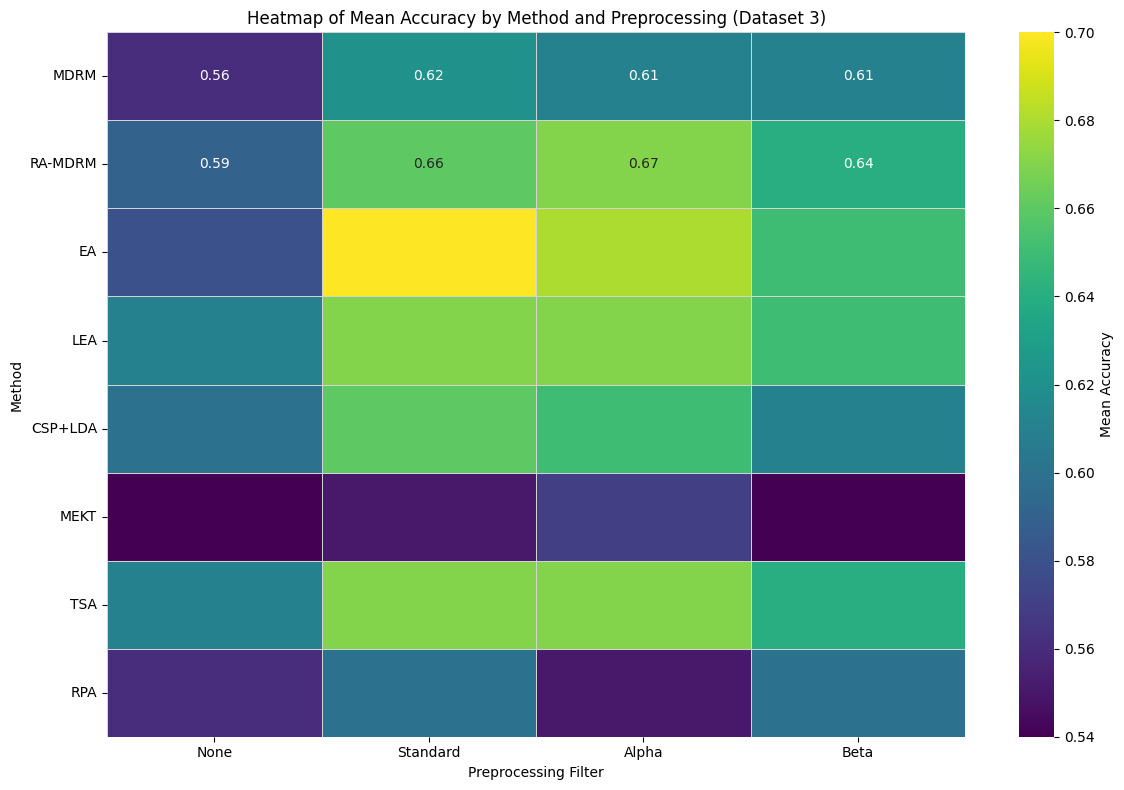


--- Generating Bar Plot ---

Error creating bar plot for the third dataset: keyword ha is not recognized; valid keywords are ['size', 'width', 'color', 'tickdir', 'pad', 'labelsize', 'labelcolor', 'labelfontfamily', 'zorder', 'gridOn', 'tick1On', 'tick2On', 'label1On', 'label2On', 'length', 'direction', 'left', 'bottom', 'right', 'top', 'labelleft', 'labelbottom', 'labelright', 'labeltop', 'labelrotation', 'grid_agg_filter', 'grid_alpha', 'grid_animated', 'grid_antialiased', 'grid_clip_box', 'grid_clip_on', 'grid_clip_path', 'grid_color', 'grid_dash_capstyle', 'grid_dash_joinstyle', 'grid_dashes', 'grid_data', 'grid_drawstyle', 'grid_figure', 'grid_fillstyle', 'grid_gapcolor', 'grid_gid', 'grid_in_layout', 'grid_label', 'grid_linestyle', 'grid_linewidth', 'grid_marker', 'grid_markeredgecolor', 'grid_markeredgewidth', 'grid_markerfacecolor', 'grid_markerfacecoloralt', 'grid_markersize', 'grid_markevery', 'grid_mouseover', 'grid_path_effects', 'grid_picker', 'grid_pickradius', 'grid_ras

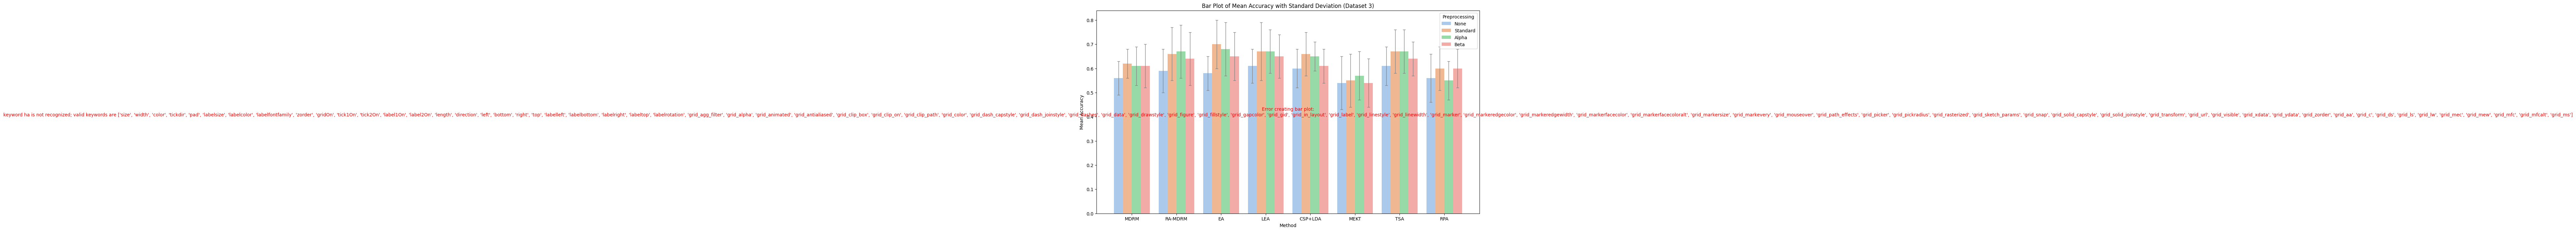

In [12]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io  # Required for saving plots to buffer

# Raw data string for the third dataset
data3 = """
MDRM

None
Subject 1 Test Accuracy: 0.48
Subject 2 Test Accuracy: 0.53
Subject 3 Test Accuracy: 0.53
Subject 4 Test Accuracy: 0.74
Subject 5 Test Accuracy: 0.54
Subject 6 Test Accuracy: 0.56
Subject 7 Test Accuracy: 0.53
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.52
Mean Cross-Validation Accuracy: 0.56 ± 0.07

Standard
Subject 1 Test Accuracy: 0.52
Subject 2 Test Accuracy: 0.53
Subject 3 Test Accuracy: 0.57
Subject 4 Test Accuracy: 0.82
Subject 5 Test Accuracy: 0.65
Subject 6 Test Accuracy: 0.70
Subject 7 Test Accuracy: 0.62
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.60
Mean Cross-Validation Accuracy: 0.62 ± 0.09

Alpha
Subject 1 Test Accuracy: 0.62
Subject 2 Test Accuracy: 0.52
Subject 3 Test Accuracy: 0.65
Subject 4 Test Accuracy: 0.78
Subject 5 Test Accuracy: 0.61
Subject 6 Test Accuracy: 0.57
Subject 7 Test Accuracy: 0.58
Subject 8 Test Accuracy: 0.58
Subject 9 Test Accuracy: 0.55
Mean Cross-Validation Accuracy: 0.61 ± 0.07

Beta
Subject 1 Test Accuracy: 0.53
Subject 2 Test Accuracy: 0.54
Subject 3 Test Accuracy: 0.52
Subject 4 Test Accuracy: 0.75
Subject 5 Test Accuracy: 0.69
Subject 6 Test Accuracy: 0.67
Subject 7 Test Accuracy: 0.60
Subject 8 Test Accuracy: 0.60
Subject 9 Test Accuracy: 0.62
Mean Cross-Validation Accuracy: 0.61 ± 0.07

RA-MDRM

None
Subject 1 Test Accuracy: 0.62
Subject 2 Test Accuracy: 0.62
Subject 3 Test Accuracy: 0.49
Subject 4 Test Accuracy: 0.76
Subject 5 Test Accuracy: 0.64
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.53
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.53
Mean Cross-Validation Accuracy: 0.59 ± 0.08

Standard
Subject 1 Test Accuracy: 0.69
Subject 2 Test Accuracy: 0.52
Subject 3 Test Accuracy: 0.58
Subject 4 Test Accuracy: 0.84
Subject 5 Test Accuracy: 0.84
Subject 6 Test Accuracy: 0.69
Subject 7 Test Accuracy: 0.61
Subject 8 Test Accuracy: 0.53
Subject 9 Test Accuracy: 0.60
Mean Cross-Validation Accuracy: 0.66 ± 0.11

Alpha
Subject 1 Test Accuracy: 0.72
Subject 2 Test Accuracy: 0.62
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.82
Subject 5 Test Accuracy: 0.71
Subject 6 Test Accuracy: 0.75
Subject 7 Test Accuracy: 0.61
Subject 8 Test Accuracy: 0.56
Subject 9 Test Accuracy: 0.57
Mean Cross-Validation Accuracy: 0.67 ± 0.08

Beta
Subject 1 Test Accuracy: 0.64
Subject 2 Test Accuracy: 0.53
Subject 3 Test Accuracy: 0.53
Subject 4 Test Accuracy: 0.81
Subject 5 Test Accuracy: 0.83
Subject 6 Test Accuracy: 0.63
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.57
Subject 9 Test Accuracy: 0.65
Mean Cross-Validation Accuracy: 0.64 ± 0.10


EA

None
Subject 1 Test Accuracy: 0.58
Subject 2 Test Accuracy: 0.64
Subject 3 Test Accuracy: 0.50
Subject 4 Test Accuracy: 0.59
Subject 5 Test Accuracy: 0.55
Subject 6 Test Accuracy: 0.53
Subject 7 Test Accuracy: 0.54
Subject 8 Test Accuracy: 0.69
Subject 9 Test Accuracy: 0.59
Mean Cross-Validation Accuracy: 0.58 ± 0.06

Standard
Subject 1 Test Accuracy: 0.69
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.58
Subject 4 Test Accuracy: 0.90
Subject 5 Test Accuracy: 0.83
Subject 6 Test Accuracy: 0.79
Subject 7 Test Accuracy: 0.58
Subject 8 Test Accuracy: 0.67
Subject 9 Test Accuracy: 0.68
Mean Cross-Validation Accuracy: 0.70 ± 0.11

Alpha
Subject 1 Test Accuracy: 0.71
Subject 2 Test Accuracy: 0.60
Subject 3 Test Accuracy: 0.57
Subject 4 Test Accuracy: 0.90
Subject 5 Test Accuracy: 0.71
Subject 6 Test Accuracy: 0.78
Subject 7 Test Accuracy: 0.58
Subject 8 Test Accuracy: 0.64
Subject 9 Test Accuracy: 0.63
Mean Cross-Validation Accuracy: 0.68 ± 0.10

Beta
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.59
Subject 3 Test Accuracy: 0.55
Subject 4 Test Accuracy: 0.88
Subject 5 Test Accuracy: 0.83
Subject 6 Test Accuracy: 0.62
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.52
Subject 9 Test Accuracy: 0.67
Mean Cross-Validation Accuracy: 0.65 ± 0.12

LEA

None
Subject 1 Test Accuracy: 0.66
Subject 2 Test Accuracy: 0.65
Subject 3 Test Accuracy: 0.48
Subject 4 Test Accuracy: 0.80
Subject 5 Test Accuracy: 0.61
Subject 6 Test Accuracy: 0.55
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.53
Mean Cross-Validation Accuracy: 0.61 ± 0.09

Standard
Subject 1 Test Accuracy: 0.68
Subject 2 Test Accuracy: 0.58
Subject 3 Test Accuracy: 0.57
Subject 4 Test Accuracy: 0.84
Subject 5 Test Accuracy: 0.84
Subject 6 Test Accuracy: 0.75
Subject 7 Test Accuracy: 0.58
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.59
Mean Cross-Validation Accuracy: 0.67 ± 0.11

Alpha
Subject 1 Test Accuracy: 0.73
Subject 2 Test Accuracy: 0.61
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.84
Subject 5 Test Accuracy: 0.69
Subject 6 Test Accuracy: 0.75
Subject 7 Test Accuracy: 0.58
Subject 8 Test Accuracy: 0.58
Subject 9 Test Accuracy: 0.56
Mean Cross-Validation Accuracy: 0.67 ± 0.09

Beta
Subject 1 Test Accuracy: 0.61
Subject 2 Test Accuracy: 0.64
Subject 3 Test Accuracy: 0.49
Subject 4 Test Accuracy: 0.79
Subject 5 Test Accuracy: 0.80
Subject 6 Test Accuracy: 0.67
Subject 7 Test Accuracy: 0.60
Subject 8 Test Accuracy: 0.60
Subject 9 Test Accuracy: 0.65
Mean Cross-Validation Accuracy: 0.65 ± 0.09

CSP+LDA

None
Subject 1 Test Accuracy: 0.58
Subject 2 Test Accuracy: 0.61
Subject 3 Test Accuracy: 0.53
Subject 4 Test Accuracy: 0.79
Subject 5 Test Accuracy: 0.57
Subject 6 Test Accuracy: 0.52
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.67
Subject 9 Test Accuracy: 0.56
Mean Cross-Validation Accuracy: 0.60 ± 0.08

Standard
Subject 1 Test Accuracy: 0.57
Subject 2 Test Accuracy: 0.54
Subject 3 Test Accuracy: 0.60
Subject 4 Test Accuracy: 0.89
Subject 5 Test Accuracy: 0.63
Subject 6 Test Accuracy: 0.79
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.64
Subject 9 Test Accuracy: 0.68
Mean Cross-Validation Accuracy: 0.66 ± 0.11

Alpha
Subject 1 Test Accuracy: 0.57
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.64
Subject 4 Test Accuracy: 0.89
Subject 5 Test Accuracy: 0.64
Subject 6 Test Accuracy: 0.76
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.64
Subject 9 Test Accuracy: 0.63
Mean Cross-Validation Accuracy: 0.65 ± 0.11

Beta
Subject 1 Test Accuracy: 0.55
Subject 2 Test Accuracy: 0.55
Subject 3 Test Accuracy: 0.53
Subject 4 Test Accuracy: 0.84
Subject 5 Test Accuracy: 0.64
Subject 6 Test Accuracy: 0.62
Subject 7 Test Accuracy: 0.61
Subject 8 Test Accuracy: 0.52
Subject 9 Test Accuracy: 0.62
Mean Cross-Validation Accuracy: 0.61 ± 0.09

MEKT

None
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.52
Subject 3 Test Accuracy: 0.43
Subject 4 Test Accuracy: 0.62
Subject 5 Test Accuracy: 0.48
Subject 6 Test Accuracy: 0.53
Subject 7 Test Accuracy: 0.53
Subject 8 Test Accuracy: 0.60
Subject 9 Test Accuracy: 0.53
Mean Cross-Validation Accuracy: 0.54 ± 0.06

Standard
Subject 1 Test Accuracy: 0.55
Subject 2 Test Accuracy: 0.47
Subject 3 Test Accuracy: 0.46
Subject 4 Test Accuracy: 0.58
Subject 5 Test Accuracy: 0.49
Subject 6 Test Accuracy: 0.77
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.65
Subject 9 Test Accuracy: 0.47
Mean Cross-Validation Accuracy: 0.55 ± 0.10

Alpha
Subject 1 Test Accuracy: 0.57
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.47
Subject 4 Test Accuracy: 0.57
Subject 5 Test Accuracy: 0.51
Subject 6 Test Accuracy: 0.75
Subject 7 Test Accuracy: 0.53
Subject 8 Test Accuracy: 0.68
Subject 9 Test Accuracy: 0.51
Mean Cross-Validation Accuracy: 0.57 ± 0.09

Beta
Subject 1 Test Accuracy: 0.52
Subject 2 Test Accuracy: 0.45
Subject 3 Test Accuracy: 0.44
Subject 4 Test Accuracy: 0.57
Subject 5 Test Accuracy: 0.50
Subject 6 Test Accuracy: 0.70
Subject 7 Test Accuracy: 0.55
Subject 8 Test Accuracy: 0.63
Subject 9 Test Accuracy: 0.46
Mean Cross-Validation Accuracy: 0.54 ± 0.08

TSA

None
Subject 1 Test Accuracy: 0.66
Subject 2 Test Accuracy: 0.61
Subject 3 Test Accuracy: 0.52
Subject 4 Test Accuracy: 0.79
Subject 5 Test Accuracy: 0.63
Subject 6 Test Accuracy: 0.49
Subject 7 Test Accuracy: 0.55
Subject 8 Test Accuracy: 0.66
Subject 9 Test Accuracy: 0.53
Mean Cross-Validation Accuracy: 0.61 ± 0.09

Standard
Subject 1 Test Accuracy: 0.68
Subject 2 Test Accuracy: 0.59
Subject 3 Test Accuracy: 0.57
Subject 4 Test Accuracy: 0.84
Subject 5 Test Accuracy: 0.84
Subject 6 Test Accuracy: 0.71
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.65
Subject 9 Test Accuracy: 0.60
Mean Cross-Validation Accuracy: 0.67 ± 0.11

Alpha
Subject 1 Test Accuracy: 0.73
Subject 2 Test Accuracy: 0.66
Subject 3 Test Accuracy: 0.64
Subject 4 Test Accuracy: 0.87
Subject 5 Test Accuracy: 0.72
Subject 6 Test Accuracy: 0.74
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.59
Subject 9 Test Accuracy: 0.53
Mean Cross-Validation Accuracy: 0.67 ± 0.10

Beta
Subject 1 Test Accuracy: 0.61
Subject 2 Test Accuracy: 0.60
Subject 3 Test Accuracy: 0.51
Subject 4 Test Accuracy: 0.79
Subject 5 Test Accuracy: 0.80
Subject 6 Test Accuracy: 0.67
Subject 7 Test Accuracy: 0.60
Subject 8 Test Accuracy: 0.58
Subject 9 Test Accuracy: 0.63
Mean Cross-Validation Accuracy: 0.64 ± 0.09

RPA

None
Subject 1 Test Accuracy: 0.49
Subject 2 Test Accuracy: 0.61
Subject 3 Test Accuracy: 0.57
Subject 4 Test Accuracy: 0.68
Subject 5 Test Accuracy: 0.47
Subject 6 Test Accuracy: 0.52
Subject 7 Test Accuracy: 0.49
Subject 8 Test Accuracy: 0.67
Subject 9 Test Accuracy: 0.53
Mean Cross-Validation Accuracy: 0.56 ± 0.07

Standard
Subject 1 Test Accuracy: 0.55
Subject 2 Test Accuracy: 0.59
Subject 3 Test Accuracy: 0.52
Subject 4 Test Accuracy: 0.82
Subject 5 Test Accuracy: 0.50
Subject 6 Test Accuracy: 0.71
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.64
Subject 9 Test Accuracy: 0.57
Mean Cross-Validation Accuracy: 0.60 ± 0.10

Alpha
Subject 1 Test Accuracy: 0.53
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.53
Subject 4 Test Accuracy: 0.53
Subject 5 Test Accuracy: 0.53
Subject 6 Test Accuracy: 0.72
Subject 7 Test Accuracy: 0.58
Subject 8 Test Accuracy: 0.50
Subject 9 Test Accuracy: 0.44
Mean Cross-Validation Accuracy: 0.55 ± 0.07

Beta
Subject 1 Test Accuracy: 0.56
Subject 2 Test Accuracy: 0.58
Subject 3 Test Accuracy: 0.50
Subject 4 Test Accuracy: 0.64
Subject 5 Test Accuracy: 0.76
Subject 6 Test Accuracy: 0.61
Subject 7 Test Accuracy: 0.50
Subject 8 Test Accuracy: 0.66
Subject 9 Test Accuracy: 0.58
Mean Cross-Validation Accuracy: 0.60 ± 0.08
"""

# Regex patterns
# Pattern to identify method names (e.g., "RA-MDRM", "EA") - assumes they are uppercase or mixed case with hyphens/plus signs
method_pattern3 = re.compile(r"^\s*([A-Za-z][A-Za-z0-9+-]+)\s*$", re.MULTILINE)
# Pattern to find preprocessing type headers
prep_pattern = re.compile(r"^(None|Standard|Alpha|Beta)$", re.MULTILINE)
# Subject and Mean patterns remain the same
subject_pattern = re.compile(r"Subject\s*(\d+)\s*Test Accuracy:\s*([\d.]+)")
mean_pattern = re.compile(r"Mean Cross-Validation Accuracy:\s*([\d.]+)\s*±\s*([\d.]+)")

# --- Parsing Logic for the Third Dataset (Line-by-Line Approach) ---
parsed_data3 = []
subject_data3 = []
current_method = None
current_prep = None

lines = data3.strip().split('\n')

# print("--- Starting Parsing ---") # DEBUG
for line_num, line in enumerate(lines):
    line = line.strip()
    # print(f"Line {line_num+1}: '{line}'") # DEBUG - Verbose line processing
    if not line:  # Skip empty lines
        continue

    # Check for Method Name
    method_match = method_pattern3.match(line)
    if method_match:
        # Check if it's not one of the preprocessing types (to avoid misidentification)
        if line not in ["None", "Standard", "Alpha", "Beta"]:
             current_method = method_match.group(1)
             # Reset preprocessing type when a new method starts
             current_prep = None
             # print(f"Found Method: {current_method}") # Debug print
             continue # Move to the next line after identifying a method

    # Check for Preprocessing Type
    prep_match = prep_pattern.match(line)
    if prep_match:
        current_prep = prep_match.group(1)
        # print(f"  Found Prep: {current_prep}") # Debug print
        continue # Move to the next line

    # If we have a current method and prep type, look for data
    if current_method and current_prep:
        # Check for Subject Accuracy
        subject_match = subject_pattern.match(line)
        if subject_match:
            subj_num = int(subject_match.group(1))
            subj_acc = float(subject_match.group(2))
            subject_data3.append({
                "Method": current_method,
                "Preprocessing": current_prep,
                "Subject": subj_num,
                "Accuracy": subj_acc
            })
            # print(f"    Added Subject: {subj_num}, Acc: {subj_acc}") # Debug print
            continue # Move to the next line

        # Check for Mean Accuracy
        mean_match = mean_pattern.match(line)
        if mean_match:
            mean_acc = float(mean_match.group(1))
            std_dev = float(mean_match.group(2))
            parsed_data3.append({
                "Method": current_method,
                "Preprocessing": current_prep,
                "MeanAccuracy": mean_acc,
                "StdDev": std_dev
            })
            # print(f"    Added Mean: {mean_acc} ± {std_dev}") # Debug print
            # Reset prep type after finding the mean for this section? No, keep it until next prep or method.
            continue # Move to the next line
    # else:
        # print(f"Skipping line (no current method/prep or no data match): {line}") # Debug print
# print("--- Finished Parsing ---") # DEBUG

# Create DataFrames for the third dataset
df_mean3 = pd.DataFrame(parsed_data3)
df_subjects3 = pd.DataFrame(subject_data3)

# --- DEBUG: Check DataFrame structure ---
# print("\n--- DEBUG: df_mean3 Info ---")
# if df_mean3.empty:
#     print("df_mean3 is EMPTY!")
# else:
#     # Use StringIO to capture the info() output as a string
#     buffer = io.StringIO()
#     df_mean3.info(buf=buffer)
#     info_str = buffer.getvalue()
#     print(info_str)
#     print("\ndf_mean3 Columns:", df_mean3.columns)
#     print("\ndf_mean3 Head:\n", df_mean3.head())
# print("--- End DEBUG: df_mean3 ---")


# Define a consistent order for preprocessing types and methods
prep_order = ["None", "Standard", "Alpha", "Beta"]
# Check if df_mean3 is not empty AND 'Method' column exists before accessing it
if not df_mean3.empty and 'Method' in df_mean3.columns:
     method_order3 = df_mean3['Method'].unique()
     # method_order3 = sorted(df_mean3['Method'].unique()) # Optional: Sort methods
else:
     method_order3 = [] # Assign empty list if DataFrame is empty or column missing
     print("Warning: Could not define method_order3 as df_mean3 is empty or missing 'Method' column.")


# --- Visualization 1: Heatmap ---
print("\n--- Generating Heatmap ---")
if not df_mean3.empty and 'Method' in df_mean3.columns and 'Preprocessing' in df_mean3.columns and 'MeanAccuracy' in df_mean3.columns:
    # Create a new figure for the heatmap
    plt.figure(figsize=(12, 8)) # Adjust size as needed

    # Create the pivot table for the heatmap
    try:
        heatmap_data3 = df_mean3.pivot_table(index="Method", columns="Preprocessing", values="MeanAccuracy")

        # Reindex both rows (Methods) and columns (Preprocessing) to ensure consistent order
        if list(method_order3): # Check if it's not empty
             heatmap_data3 = heatmap_data3.reindex(index=method_order3, columns=prep_order)
        else:
             heatmap_data3 = heatmap_data3.reindex(columns=prep_order) # Reindex columns only if method order is invalid

        # Generate the heatmap on the current figure
        sns.heatmap(heatmap_data3, annot=True, fmt=".2f", cmap="viridis", linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'Mean Accuracy'})
        plt.title('Heatmap of Mean Accuracy by Method and Preprocessing (Dataset 3)')
        plt.xlabel('Preprocessing Filter')
        plt.ylabel('Method')
        plt.xticks(rotation=0) # Horizontal labels
        plt.yticks(rotation=0) # Horizontal labels
        plt.tight_layout() # Adjust layout for this figure
        plt.show() # Display the heatmap figure

    except Exception as e:
        print(f"\nError creating heatmap for the third dataset: {e}")
        # Optionally display error on a blank plot if plt is still usable
        plt.text(0.5, 0.5, f"Error creating heatmap:\n{e}", ha='center', va='center', color='red')
        plt.show()

else:
    print("\nNo data available or missing required columns to generate the heatmap for the third dataset.")
    # Optionally create a blank plot indicating missing data
    plt.figure(figsize=(12, 8))
    plt.text(0.5, 0.5, "No data available or missing columns for heatmap", ha='center', va='center')
    plt.title('Heatmap Placeholder')
    plt.show()


# --- Visualization 2: Bar Plot ---
print("\n--- Generating Bar Plot ---")
if not df_mean3.empty and 'Method' in df_mean3.columns and 'Preprocessing' in df_mean3.columns and 'MeanAccuracy' in df_mean3.columns and 'StdDev' in df_mean3.columns:
    # Create a new figure for the bar plot
    plt.figure(figsize=(15, 8)) # Adjust size as needed
    ax_barplot = plt.gca() # Get current axes for the new figure

    # Create the bar plot
    try:
        # Plotting with error bars using StdDev
        sns.barplot(data=df_mean3, x='Method', y='MeanAccuracy', hue='Preprocessing',
                    order=method_order3 if list(method_order3) else None, # Use order only if valid
                    hue_order=prep_order, palette='pastel', ax=ax_barplot) # Use current axes

        # --- Manually add error bars using StdDev ---
        if len(ax_barplot.patches) > 0 and list(method_order3):
             num_methods = len(method_order3)
             num_preps = len(prep_order)
             x_coords = [patch.get_x() + patch.get_width() / 2. for patch in ax_barplot.patches]
             y_coords = [patch.get_height() for patch in ax_barplot.patches]
             bar_labels = []

             for i, method in enumerate(method_order3):
                 for j, prep in enumerate(prep_order):
                      bar_index = i * num_preps + j
                      if bar_index < len(ax_barplot.patches):
                          bar_labels.append((method, prep))

             if len(bar_labels) == len(x_coords):
                  std_dev_map = df_mean3.set_index(['Method', 'Preprocessing'])['StdDev']
                  for i in range(len(x_coords)):
                      method, prep = bar_labels[i]
                      if (method, prep) in std_dev_map.index:
                          std_dev_val = std_dev_map.loc[(method, prep)]
                          lower_error = min(y_coords[i], std_dev_val)
                          ax_barplot.errorbar(x_coords[i], y_coords[i], yerr=[[lower_error], [std_dev_val]],
                                              fmt='none', color='gray', capsize=3, elinewidth=1)
             else:
                  print("Warning: Mismatch between number of bars and labels for error bars.")

        ax_barplot.set_title('Bar Plot of Mean Accuracy with Standard Deviation (Dataset 3)')
        ax_barplot.set_xlabel('Method')
        ax_barplot.set_ylabel('Mean Accuracy')
        ax_barplot.tick_params(axis='x', rotation=45, ha='right')
        min_y = df_mean3['MeanAccuracy'].min() - df_mean3['StdDev'].max() - 0.05
        max_y = df_mean3['MeanAccuracy'].max() + df_mean3['StdDev'].max() + 0.05
        ax_barplot.set_ylim(bottom=max(0, min_y), top=min(1.0, max_y))
        ax_barplot.legend(title='Preprocessing', loc='upper right')
        ax_barplot.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout() # Adjust layout for this figure
        plt.show() # Display the bar plot figure

    except Exception as e:
        print(f"\nError creating bar plot for the third dataset: {e}")
        # Optionally display error on the current plot
        plt.text(0.5, 0.5, f"Error creating bar plot:\n{e}", ha='center', va='center', color='red', transform=ax_barplot.transAxes)
        plt.show()

else:
    print("\nNo data available or missing required columns to generate the bar plot for the third dataset.")
    # Optionally create a blank plot indicating missing data
    plt.figure(figsize=(15, 8))
    plt.text(0.5, 0.5, "No data available or missing columns for bar plot", ha='center', va='center')
    plt.title('Bar Plot Placeholder')
    plt.show()


# Optional: Save the figures to files
# fig_heatmap = plt.figure(1) # Assuming heatmap was figure 1
# fig_heatmap.savefig("dataset3_heatmap.png", dpi=300)
# fig_barplot = plt.figure(2) # Assuming bar plot was figure 2
# fig_barplot.savefig("dataset3_barplot.png", dpi=300)
